In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
 
# -----------------------------
# Config
# -----------------------------
xlsx_path = "../../../data/processed/clinical/Subjects_data.xlsx"
 
# Column letters: F = Early progression, R = baseline Hb
# Excel letters -> 0-based index: A=0, B=1, ..., F=5, R=17
EARLY_COL_IDX = 5   # F
HB_COL_IDX    = 17  # R
 
out_svg = "Hb_baseline_violin_Early_vs_NonEarly_gdL.svg"
 




In [2]:
# -----------------------------
# Helpers
# -----------------------------
def p_to_stars(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"
 
def coerce_binary(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (bool, np.bool_)):
        return int(x)
    if isinstance(x, (int, float, np.integer, np.floating)):
        if x in [0, 1]:
            return int(x)
    s = str(x).strip().lower()
    if s in ["1", "true", "yes", "y", "early", "early pd", "early progression"]:
        return 1
    if s in ["0", "false", "no", "n", "non-early", "not early", "non early", "late", "non-early pd"]:
        return 0
    try:
        return int(float(s))
    except:
        return np.nan
 
def summarize(x):
    x = np.asarray(x, dtype=float)
    mean = np.mean(x)
    sd = np.std(x, ddof=1) if len(x) > 1 else np.nan
    med = np.median(x)
    q1 = np.quantile(x, 0.25)
    q3 = np.quantile(x, 0.75)
    return mean, sd, med, q1, q3

 
def cliffs_delta(x, y):
    """
    Cliff's delta: P(X>Y) - P(X<Y), ranges [-1, 1].
    x = group1, y = group2
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    gt = 0
    lt = 0
    # O(n*m) but fine for n~26, m~147
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    n = len(x) * len(y)
    return (gt - lt) / n
 

# Hemoglobin

In [3]:
# -----------------------------
# Load
# -----------------------------
df = pd.read_excel(xlsx_path)
 
early_col = 'Early_PD'
hb_col    = 'Hemoglobin_g_per_dL'
 
early = df[early_col].apply(coerce_binary)
hb = pd.to_numeric(df[hb_col], errors="coerce")  # KEEP AS-IS (g/dL)
 
tmp = pd.DataFrame({"early": early, "hb_g_dL": hb}).dropna()
 
hb_early = tmp.loc[tmp["early"] == 1, "hb_g_dL"].to_numpy()
hb_nonearly = tmp.loc[tmp["early"] == 0, "hb_g_dL"].to_numpy()
 
print(f"N (Early): {len(hb_early)} | N (Non-early): {len(hb_nonearly)}")
 
m1, sd1, med1, q11, q31 = summarize(hb_early)
m0, sd0, med0, q10, q30 = summarize(hb_nonearly)
 
print("\nGroup summaries (Hb, g/dL):")
print(f"  Early PD:     mean={m1:.2f} (SD {sd1:.2f}); median={med1:.2f} (IQR {q11:.2f}–{q31:.2f})")
print(f"  Non-early PD: mean={m0:.2f} (SD {sd0:.2f}); median={med0:.2f} (IQR {q10:.2f}–{q30:.2f})")
 
# Mann–Whitney U
u_stat, p_val = mannwhitneyu(hb_early, hb_nonearly, alternative="two-sided", method="asymptotic")
stars = p_to_stars(p_val)
print(f"\nMann–Whitney U p-value: {p_val:.4g} ({stars})")

N (Early): 26 | N (Non-early): 147

Group summaries (Hb, g/dL):
  Early PD:     mean=12.44 (SD 1.40); median=12.85 (IQR 11.53–13.47)
  Non-early PD: mean=12.91 (SD 1.53); median=13.10 (IQR 12.10–13.80)

Mann–Whitney U p-value: 0.1596 (ns)


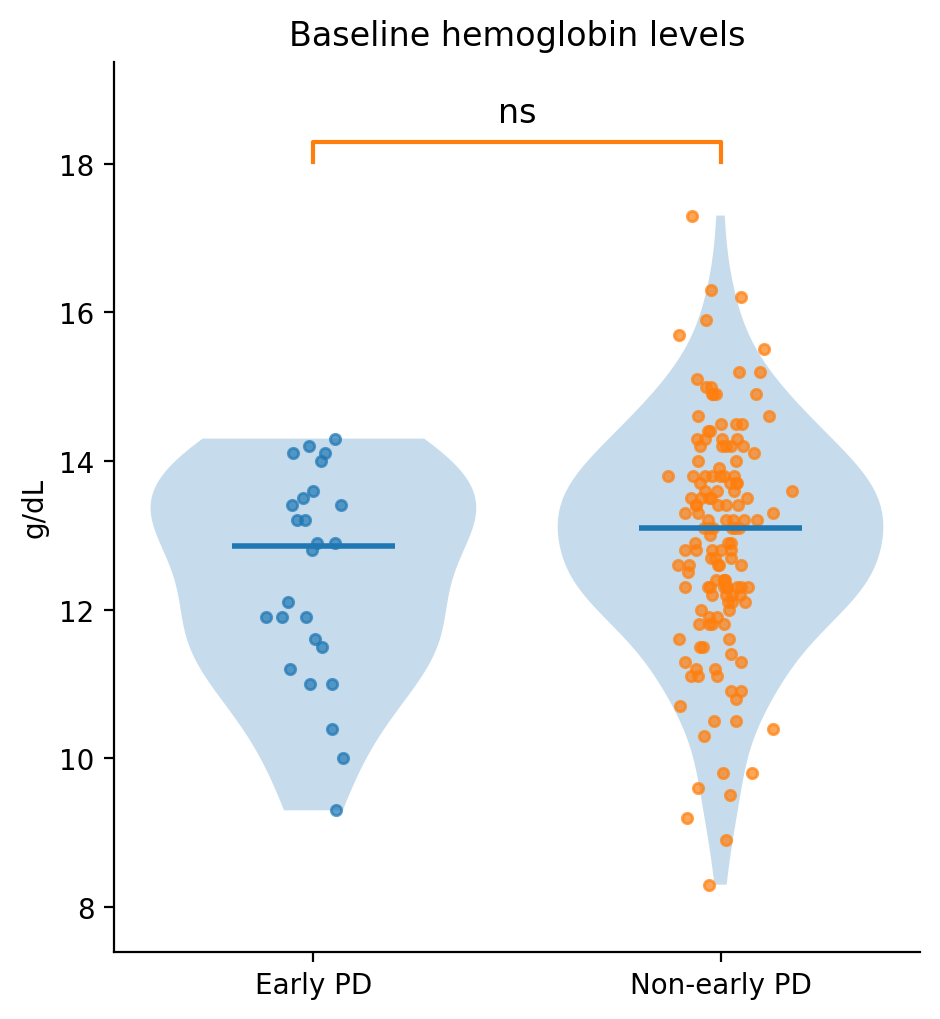


Saved: Hb_baseline_violin_Early_vs_NonEarly_gdL.svg


In [4]:
 
# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4.8, 5.2), dpi=200)
 
data = [hb_early, hb_nonearly]
positions = [1, 2]
 
vp = ax.violinplot(
    data,
    positions=positions,
    widths=0.8,
    showmeans=False,
    showmedians=True,
    showextrema=False
)
 
for b in vp['bodies']:
    b.set_alpha(0.25)
vp['cmedians'].set_linewidth(2)
 
# points (jitter)
rng = np.random.default_rng(42)
for i, y in enumerate(data):
    x = np.full_like(y, positions[i], dtype=float)
    jitter = rng.normal(0, 0.06, size=len(y))
    ax.scatter(x + jitter, y, s=14, alpha=0.7)
 
ax.set_xticks(positions)
ax.set_xticklabels(["Early PD", "Non-early PD"])
ax.set_ylabel("g/dL")
ax.set_title("Baseline hemoglobin levels")
 
# p-value bracket
y_all = np.concatenate(data)
y_max = float(np.max(y_all))
y_min = float(np.min(y_all))
y_range = y_max - y_min if y_max > y_min else 1.0
 
bar_y = y_max + 0.08 * y_range
bar_h = 0.03 * y_range
 
ax.plot([1, 1, 2, 2], [bar_y, bar_y + bar_h, bar_y + bar_h, bar_y], lw=1.5)
ax.text(1.5, bar_y + bar_h + 0.02 * y_range, stars, ha="center", va="bottom", fontsize=12)
#ax.text(1.5, bar_y + bar_h + 0.002 * y_range, f"p={p_val:.2e}", ha="center", va="bottom", fontsize=8)
 
ax.set_ylim(y_min - 0.1 * y_range, bar_y + bar_h + 0.12 * y_range)
import seaborn as sns
sns.despine()
plt.tight_layout()
#fig.savefig(out_svg, bbox_inches="tight")
plt.show()
 
print("\nSaved:", out_svg)

# NLR

In [5]:
# Define NLR
lymph_col = 'Linfocytes_thousands_per_mm3'
neut_col  = 'Neutrophils_thousands_per_mm3'

lymph = pd.to_numeric(df[lymph_col], errors="coerce")
neut  = pd.to_numeric(df[neut_col], errors="coerce")
 
# NLR
# Avoid division by zero / negative / missing
nlr = neut / lymph
nlr = nlr.replace([np.inf, -np.inf], np.nan)
nlr = nlr.where((lymph > 0) & (neut >= 0))  # keep only sensible values

tmp = pd.DataFrame({"early": early, "NLR": nlr}).dropna()
 
nlr_early = tmp.loc[tmp["early"] == 1, "NLR"].to_numpy()
nlr_nonearly = tmp.loc[tmp["early"] == 0, "NLR"].to_numpy()
 
print(f"N (Early): {len(nlr_early)} | N (Non-early): {len(nlr_nonearly)}")
 
m1, sd1, med1, q11, q31 = summarize(nlr_early)
m0, sd0, med0, q10, q30 = summarize(nlr_nonearly)
 
print("\nGroup summaries (NLR):")
print(f"  Early PD:     mean={m1:.2f} (SD {sd1:.2f}); median={med1:.2f} (IQR {q11:.2f}–{q31:.2f})")
print(f"  Non-early PD: mean={m0:.2f} (SD {sd0:.2f}); median={med0:.2f} (IQR {q10:.2f}–{q30:.2f})")
 
# Mann–Whitney U
u_stat, p_val = mannwhitneyu(nlr_early, nlr_nonearly, alternative="two-sided", method="asymptotic")
stars = p_to_stars(p_val)
print(f"\nMann–Whitney U p-value: {p_val:.4g} ({stars})")

N (Early): 26 | N (Non-early): 147

Group summaries (NLR):
  Early PD:     mean=7.00 (SD 11.13); median=3.33 (IQR 2.10–6.00)
  Non-early PD: mean=2.93 (SD 2.22); median=2.42 (IQR 1.62–3.56)

Mann–Whitney U p-value: 0.01947 (*)


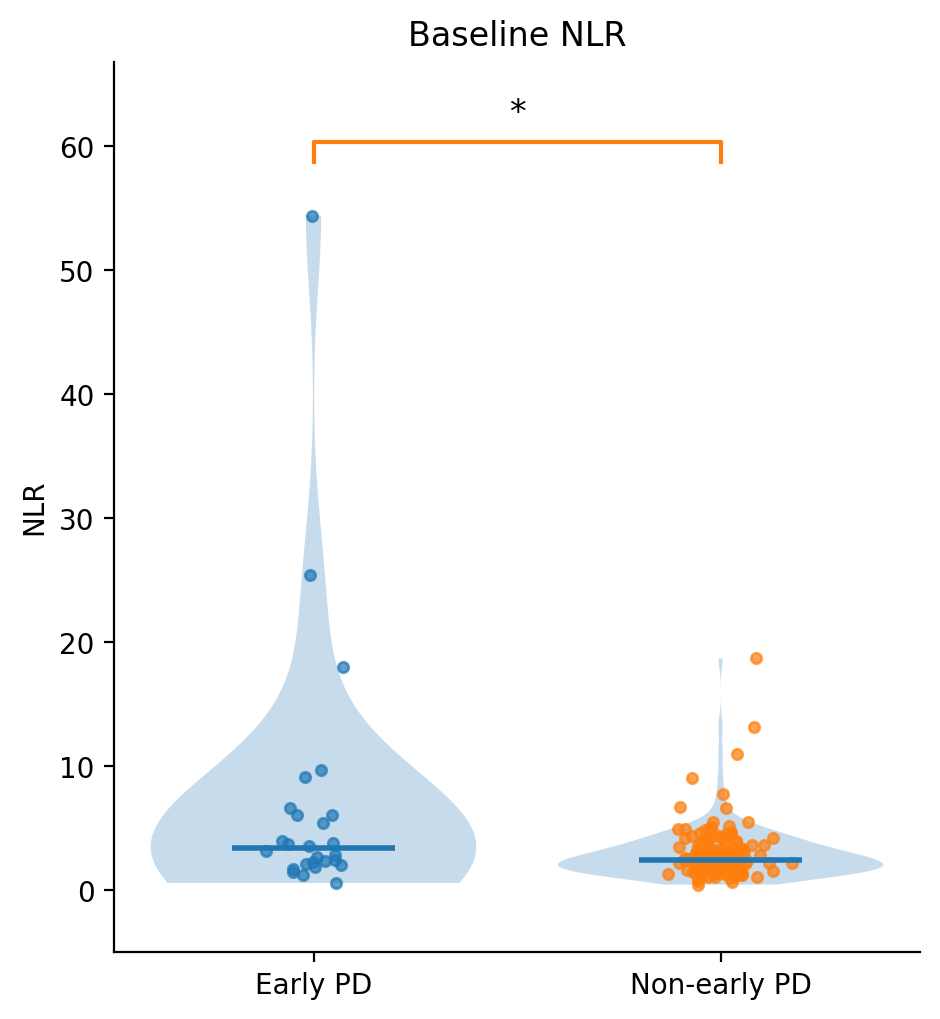


Saved: Hb_baseline_violin_Early_vs_NonEarly_gdL.svg


In [6]:
# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4.8, 5.2), dpi=200)
 
data = [nlr_early, nlr_nonearly]
positions = [1, 2]
 
vp = ax.violinplot(
    data,
    positions=positions,
    widths=0.8,
    showmeans=False,
    showmedians=True,
    showextrema=False
)
 
for b in vp['bodies']:
    b.set_alpha(0.25)
vp['cmedians'].set_linewidth(2)
 
# points with jitter
rng = np.random.default_rng(42)
for i, y in enumerate(data):
    x = np.full_like(y, positions[i], dtype=float)
    jitter = rng.normal(0, 0.06, size=len(y))
    ax.scatter(x + jitter, y, s=14, alpha=0.7)
 
ax.set_xticks(positions)
ax.set_xticklabels(["Early PD", "Non-early PD"])
ax.set_ylabel("NLR")
ax.set_title("Baseline NLR")
 
# p-value bracket
y_all = np.concatenate(data)
y_max = float(np.max(y_all))
y_min = float(np.min(y_all))
y_range = y_max - y_min if y_max > y_min else 1.0
 
bar_y = y_max + 0.08 * y_range
bar_h = 0.03 * y_range
 
ax.plot([1, 1, 2, 2], [bar_y, bar_y + bar_h, bar_y + bar_h, bar_y], lw=1.5)
ax.text(1.5, bar_y + bar_h + 0.02 * y_range, stars, ha="center", va="bottom", fontsize=12)
#ax.text(1.5, bar_y + bar_h + 0.002 * y_range, f"p={p_val:.2e}", ha="center", va="bottom", fontsize=8)
 
ax.set_ylim(y_min - 0.1 * y_range, bar_y + bar_h + 0.12 * y_range)
import seaborn as sns
sns.despine()
plt.tight_layout()
#fig.savefig(out_svg, bbox_inches="tight")
plt.show()
 
print("\nSaved:", out_svg)

# SII

In [7]:
plt_col   = 'Platelets_thousands_per_mm3'
 
early = df[early_col].apply(coerce_binary)
lymph = pd.to_numeric(df[lymph_col], errors="coerce")
neut  = pd.to_numeric(df[neut_col], errors="coerce")
plt_  = pd.to_numeric(df[plt_col], errors="coerce")
 
# SII
sii = (plt_ * neut) / lymph
sii = sii.replace([np.inf, -np.inf], np.nan)
sii = sii.where((lymph > 0) & (neut >= 0) & (plt_ >= 0))

tmp = pd.DataFrame({"early": early, "SII": sii}).dropna()
 
sii_early = tmp.loc[tmp["early"] == 1, "SII"].to_numpy()
sii_nonearly = tmp.loc[tmp["early"] == 0, "SII"].to_numpy()
 
print(f"N (Early): {len(sii_early)} | N (Non-early): {len(sii_nonearly)}")
 
m1, sd1, med1, q11, q31 = summarize(sii_early)
m0, sd0, med0, q10, q30 = summarize(sii_nonearly)
 
print("\nGroup summaries (SII):")
print(f"  Early PD:     mean={m1:.2f} (SD {sd1:.2f}); median={med1:.2f} (IQR {q11:.2f}–{q31:.2f})")
print(f"  Non-early PD: mean={m0:.2f} (SD {sd0:.2f}); median={med0:.2f} (IQR {q10:.2f}–{q30:.2f})")
 
u_stat, p_val = mannwhitneyu(sii_early, sii_nonearly, alternative="two-sided", method="asymptotic")
stars = p_to_stars(p_val)
print(f"\nMann–Whitney U p-value: {p_val:.4g} ({stars})")
 
# Cliff's delta (Early vs Non-early)
cd = cliffs_delta(sii_early, sii_nonearly)
print(f"Cliff's delta (Early vs Non-early): {cd:.3f}")

N (Early): 26 | N (Non-early): 147

Group summaries (SII):
  Early PD:     mean=2208.02 (SD 3140.27); median=876.35 (IQR 549.15–1813.44)
  Non-early PD: mean=854.65 (SD 795.51); median=616.63 (IQR 389.74–1014.71)

Mann–Whitney U p-value: 0.01511 (*)
Cliff's delta (Early vs Non-early): 0.300


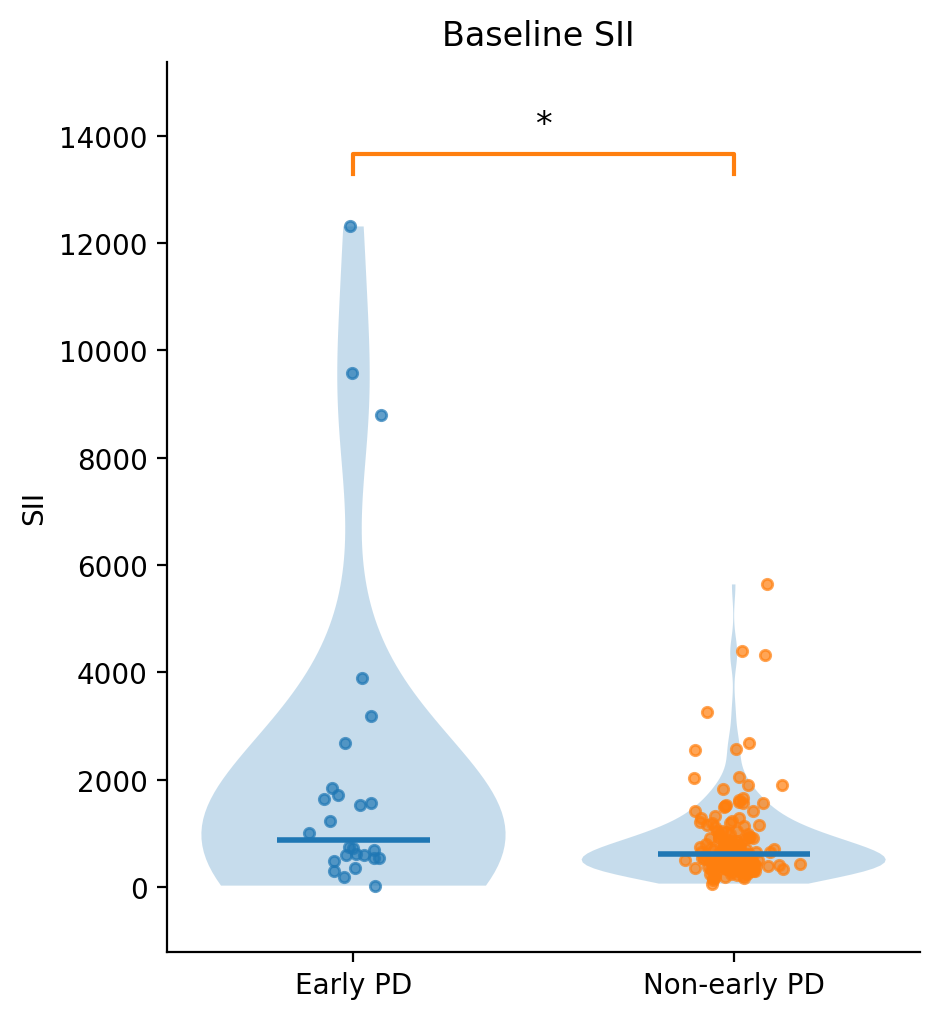


Saved: Hb_baseline_violin_Early_vs_NonEarly_gdL.svg


In [8]:
# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4.8, 5.2), dpi=200)
 
data = [sii_early, sii_nonearly]
positions = [1, 2]
 
vp = ax.violinplot(
    data,
    positions=positions,
    widths=0.8,
    showmeans=False,
    showmedians=True,
    showextrema=False
)
for b in vp['bodies']:
    b.set_alpha(0.25)
vp['cmedians'].set_linewidth(2)
 
rng = np.random.default_rng(42)
for i, y in enumerate(data):
    x = np.full_like(y, positions[i], dtype=float)
    jitter = rng.normal(0, 0.06, size=len(y))
    ax.scatter(x + jitter, y, s=14, alpha=0.7)
 
ax.set_xticks(positions)
ax.set_xticklabels(["Early PD", "Non-early PD"])
ax.set_ylabel("SII")
ax.set_title("Baseline SII ")
 
y_all = np.concatenate(data)
y_max = float(np.max(y_all))
y_min = float(np.min(y_all))
y_range = y_max - y_min if y_max > y_min else 1.0
 
bar_y = y_max + 0.08 * y_range
bar_h = 0.03 * y_range
 
ax.plot([1, 1, 2, 2], [bar_y, bar_y + bar_h, bar_y + bar_h, bar_y], lw=1.5)
ax.text(1.5, bar_y + bar_h + 0.02 * y_range, stars, ha="center", va="bottom", fontsize=12)
#ax.text(1.5, bar_y + bar_h + 0.002 * y_range, f"p={p_val:.2e}", ha="center", va="bottom", fontsize=8)
 
# Optional: annotate Cliff's delta
#ax.text(1.5, bar_y + bar_h + 0.06 * y_range, f"Cliff’s δ={cd:.2f}", ha="center", va="bottom", fontsize=9)
 
ax.set_ylim(y_min - 0.1 * y_range, bar_y + bar_h + 0.14 * y_range)
import seaborn as sns
sns.despine()
plt.tight_layout()
#fig.savefig(out_svg, bbox_inches="tight")
plt.show()
 
print("\nSaved:", out_svg)

# Albumin

In [9]:
alb = pd.to_numeric(df['Albumin_g_per_dL'], errors="coerce")


In [10]:
def violin_compare(df, early_series, value_series, y_label, title, out_prefix):
    tmp = pd.DataFrame({"early": early_series, "val": value_series}).dropna()
    g1 = tmp.loc[tmp["early"] == 1, "val"].to_numpy()
    g0 = tmp.loc[tmp["early"] == 0, "val"].to_numpy()
 
    print("\n" + "="*80)
    print(title)
    print(f"N (Early): {len(g1)} | N (Non-early): {len(g0)}")
 
    m1, sd1, med1, q11, q31 = summarize(g1)
    m0, sd0, med0, q10, q30 = summarize(g0)
    print(f"  Early PD:     mean={m1:.2f} (SD {sd1:.2f}); median={med1:.2f} (IQR {q11:.2f}–{q31:.2f})")
    print(f"  Non-early PD: mean={m0:.2f} (SD {sd0:.2f}); median={med0:.2f} (IQR {q10:.2f}–{q30:.2f})")
 
    u_stat, p_val = mannwhitneyu(g1, g0, alternative="two-sided", method="asymptotic")
    stars = p_to_stars(p_val)
    cd = cliffs_delta(g1, g0)
    p_superiority = (cd + 1) / 2
 
    print(f"  Mann–Whitney p={p_val:.4g} ({stars})")
    print(f"  Cliff's δ={cd:.3f} | P(Early > Non-early)≈{p_superiority:.3f}")
 
    # Plot
    fig, ax = plt.subplots(figsize=(4.8, 5.2), dpi=200)
 
    data = [g1, g0]
    positions = [1, 2]
    vp = ax.violinplot(data, positions=positions, widths=0.8,
                       showmeans=False, showmedians=True, showextrema=False)
    for b in vp['bodies']:
        b.set_alpha(0.25)
    vp['cmedians'].set_linewidth(2)
 
    rng = np.random.default_rng(42)
    for i, y in enumerate(data):
        x = np.full_like(y, positions[i], dtype=float)
        jitter = rng.normal(0, 0.06, size=len(y))
        ax.scatter(x + jitter, y, s=14, alpha=0.7)
 
    ax.set_xticks(positions)
    ax.set_xticklabels(["Early PD", "Non-early PD"])
    ax.set_ylabel(y_label)
    ax.set_title(title)
 
    # p-value bracket
    y_all = np.concatenate(data)
    y_max = float(np.max(y_all))
    y_min = float(np.min(y_all))
    y_range = y_max - y_min if y_max > y_min else 1.0
    bar_y = y_max + 0.08 * y_range
    bar_h = 0.03 * y_range
 
    ax.plot([1, 1, 2, 2], [bar_y, bar_y + bar_h, bar_y + bar_h, bar_y], lw=1.5)
    ax.text(1.5, bar_y + bar_h + 0.02 * y_range, stars, ha="center", va="bottom", fontsize=12)
    #ax.text(1.5, bar_y + bar_h + 0.002 * y_range, f"p={p_val:.2e}", ha="center", va="bottom", fontsize=8)
    #ax.text(1.5, bar_y + bar_h + 0.06 * y_range, f"Cliff’s δ={cd:.2f}", ha="center", va="bottom", fontsize=9)
 
    ax.set_ylim(y_min - 0.1 * y_range, bar_y + bar_h + 0.14 * y_range)
    import seaborn as sns
    sns.despine()
    plt.tight_layout()
    #fig.savefig(out_prefix + ".svg", bbox_inches="tight")
    plt.show()
 


Baseline albumin levels
N (Early): 21 | N (Non-early): 110
  Early PD:     mean=4.14 (SD 0.42); median=4.18 (IQR 3.90–4.40)
  Non-early PD: mean=4.26 (SD 0.41); median=4.30 (IQR 4.00–4.50)
  Mann–Whitney p=0.2619 (ns)
  Cliff's δ=-0.155 | P(Early > Non-early)≈0.423


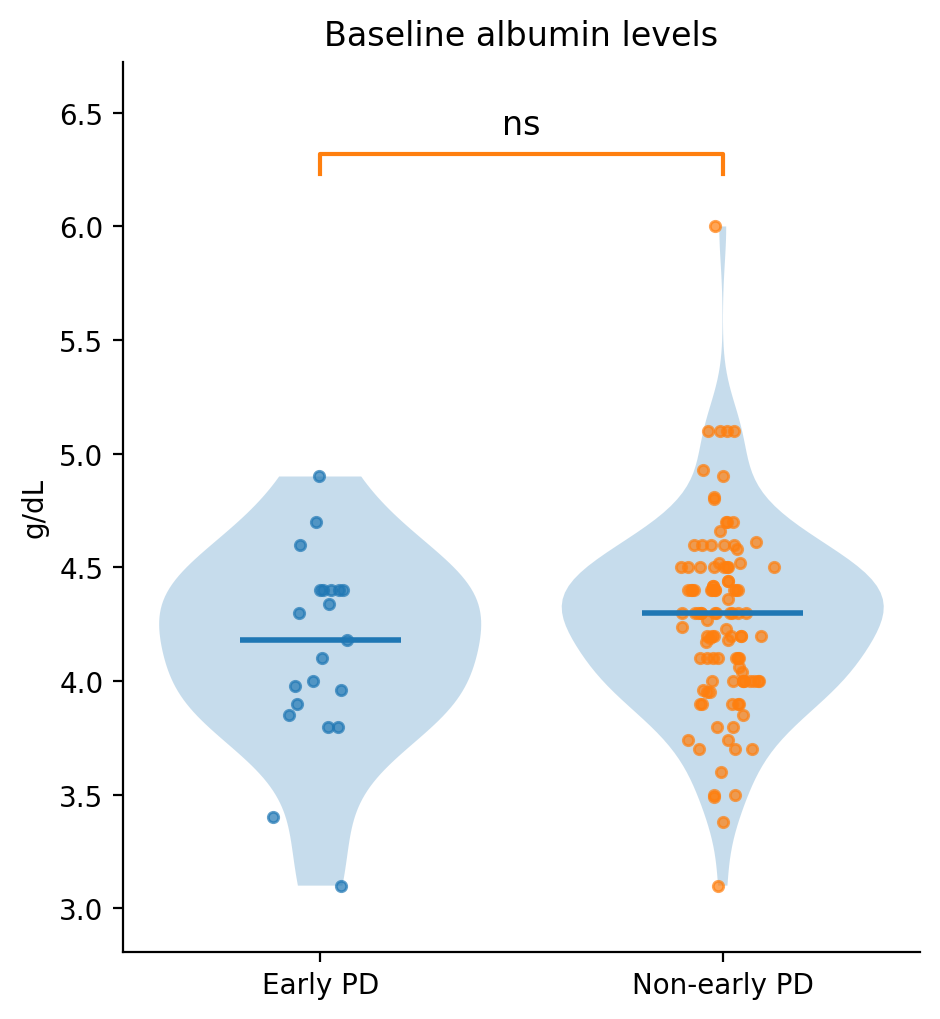

In [11]:
violin_compare(df, early, alb,
               y_label="g/dL",
               title="Baseline albumin levels",
               out_prefix="Albumin_baseline_violin_Early_vs_NonEarly")